In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("prof_components_extracted")
firms_plot5 = ["EQNR.OL", "AKRBP.OL", "NHY.OL"]

# ---------- Load ALL firm CSVs into one panel ----------
MIN_YEAR = 2005
MAX_YEAR = 2024

rows = []
for fp in sorted(DATA_DIR.glob("*.csv")):
    firm = fp.stem
    df = pd.read_csv(fp)
    if "Year" not in df.columns:
        df = pd.read_csv(fp, index_col=0).reset_index().rename(columns={"index": "Year"})

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)

    # Year window applied here (affects all downstream plots)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].sort_values("Year")

    df["firm"] = firm
    rows.append(df)

panel = pd.concat(rows, ignore_index=True)

# Ensure PROF exists
if "PROF" not in panel.columns:
    raise ValueError("Column 'PROF' not found. Make sure you've computed PROF and saved it in each CSV.")


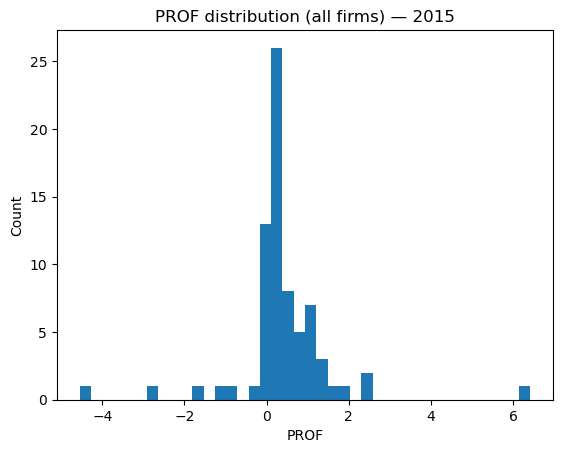

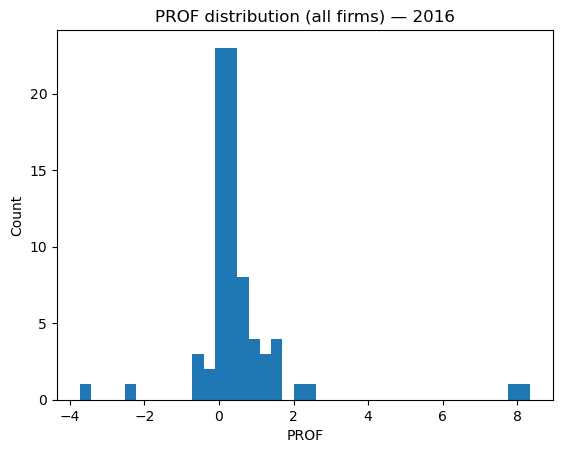

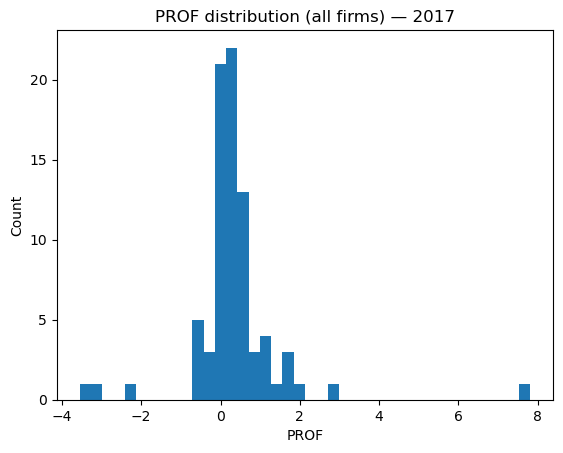

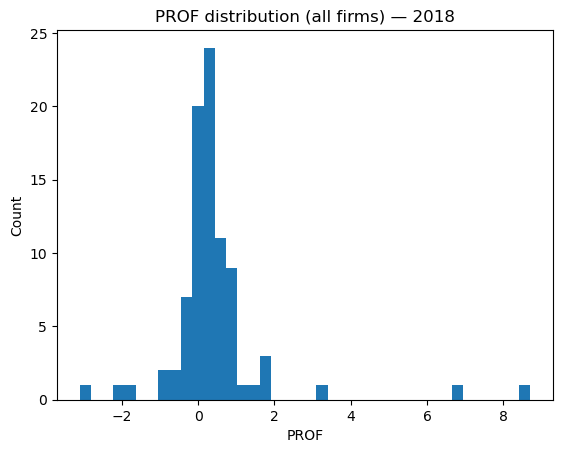

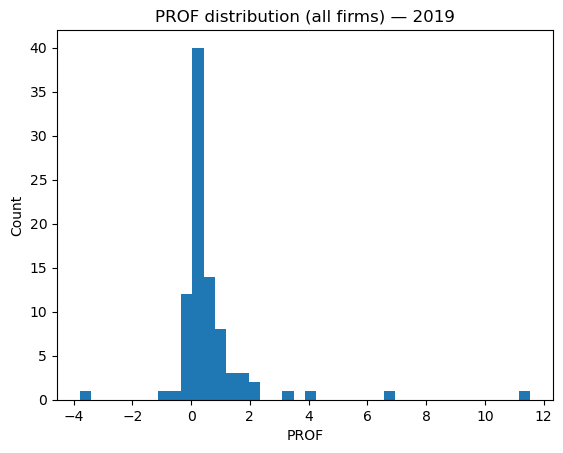

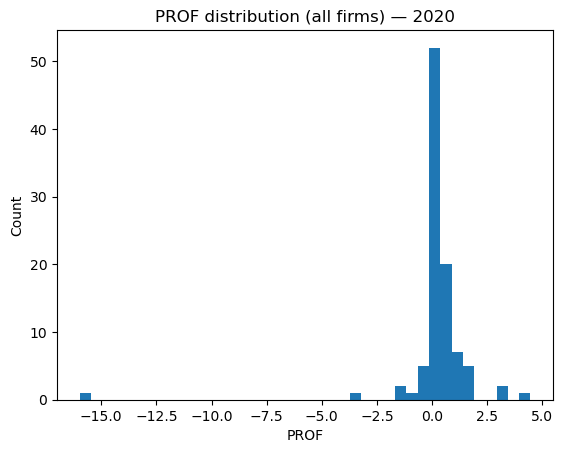

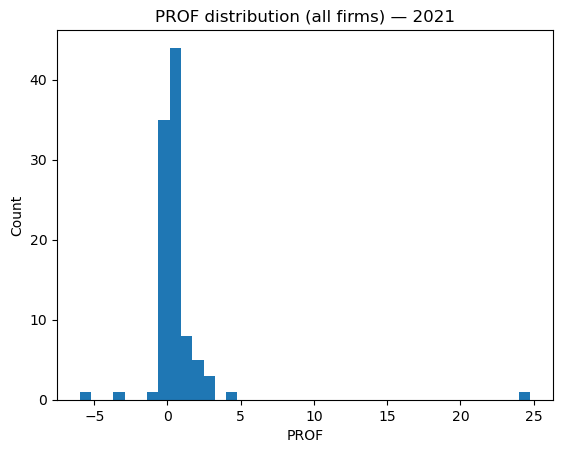

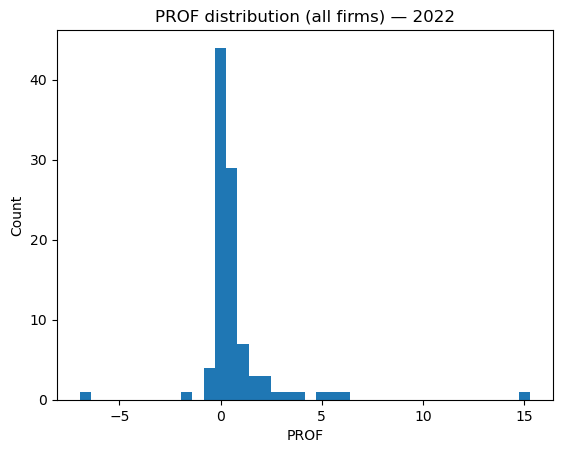

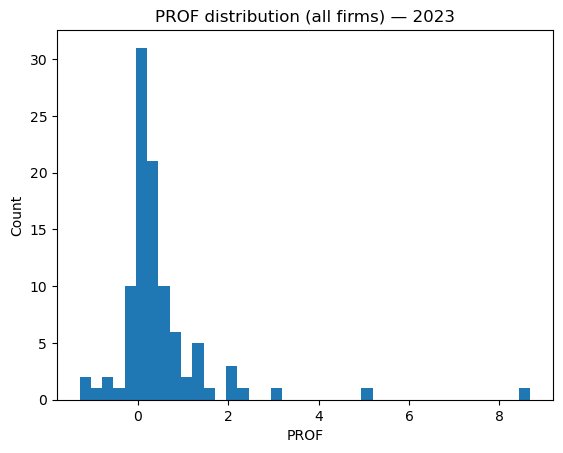

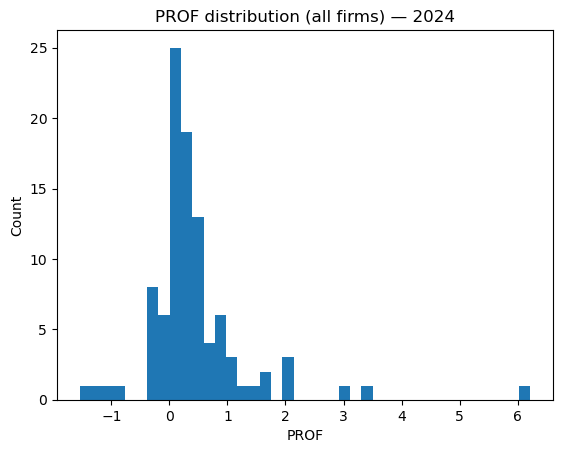

In [9]:

# ---------- Plot 1: PROF distribution each year (ALL firms) ----------
years = sorted(panel["Year"].unique())
years_to_plot = years[-10:] if len(years) > 10 else years  # last 10 years if many

for y in years_to_plot:
    vals = panel.loc[panel["Year"] == y, "PROF"].replace([np.inf, -np.inf], np.nan).dropna()
    plt.figure()
    plt.hist(vals, bins=40)
    plt.title(f"PROF distribution (all firms) — {y}")
    plt.xlabel("PROF")
    plt.ylabel("Count")
    plt.show()


/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_30229/3868926889.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mom = panel.groupby("Year").apply(moments).reset_index()


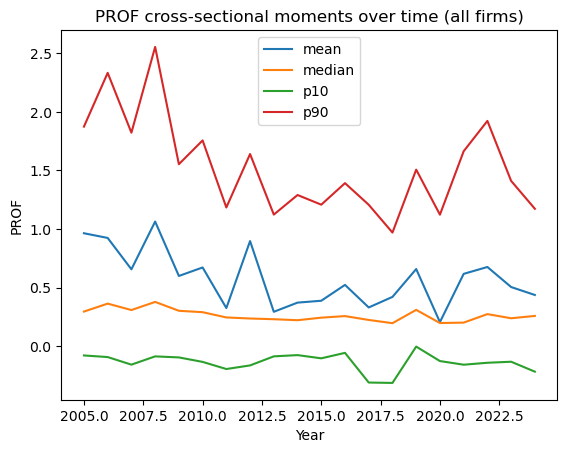

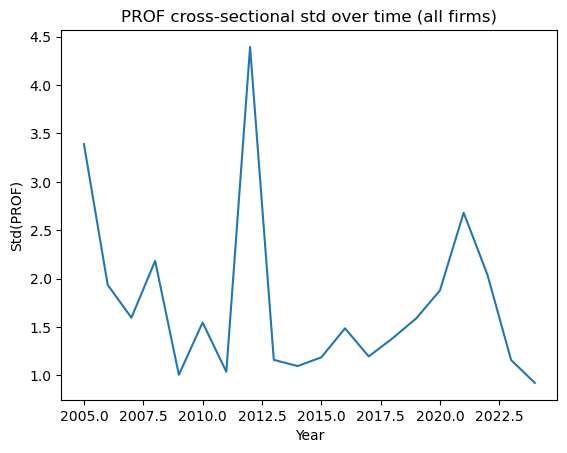

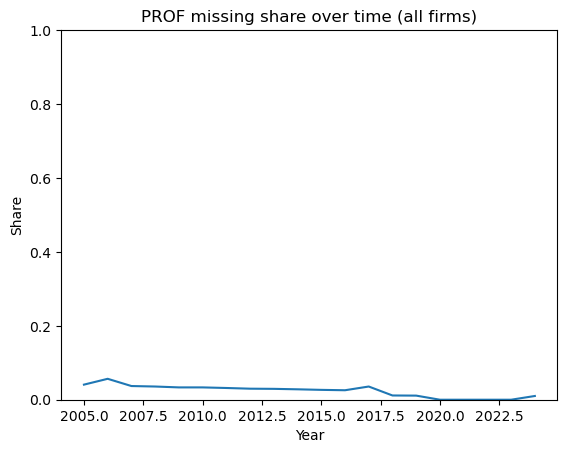

In [10]:

# ---------- Plot 2: Cross-sectional moments over time (ALL firms) ----------
def moments(g):
    s = g["PROF"].replace([np.inf, -np.inf], np.nan)
    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "p10": s.quantile(0.10),
        "p90": s.quantile(0.90),
        "std": s.std(),
        "n": s.notna().sum(),
        "nan_share": 1 - s.notna().mean(),
    })

mom = panel.groupby("Year").apply(moments).reset_index()

plt.figure()
plt.plot(mom["Year"], mom["mean"], label="mean")
plt.plot(mom["Year"], mom["median"], label="median")
plt.plot(mom["Year"], mom["p10"], label="p10")
plt.plot(mom["Year"], mom["p90"], label="p90")
plt.title("PROF cross-sectional moments over time (all firms)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["std"])
plt.title("PROF cross-sectional std over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Std(PROF)")
plt.show()

plt.figure()
plt.plot(mom["Year"], mom["nan_share"])
plt.title("PROF missing share over time (all firms)")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.show()


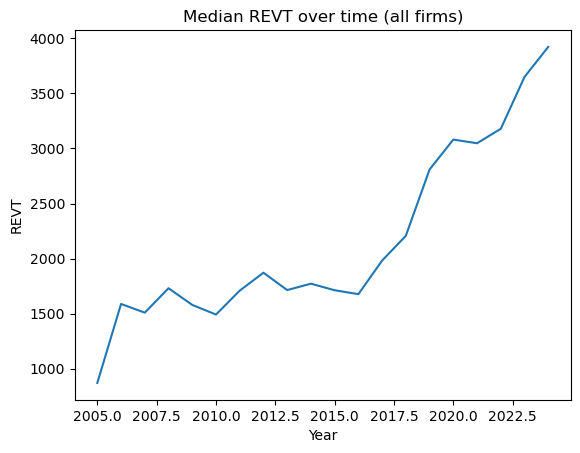

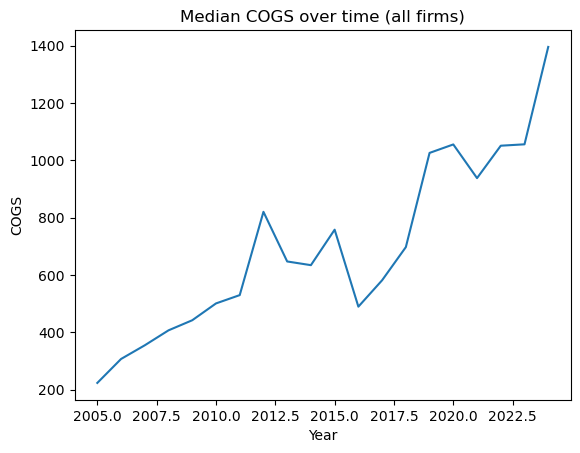

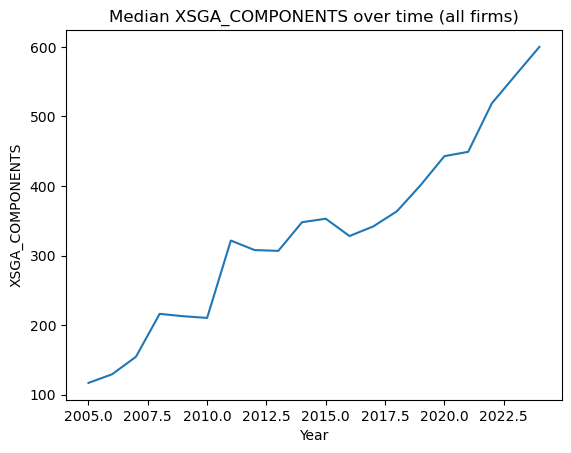

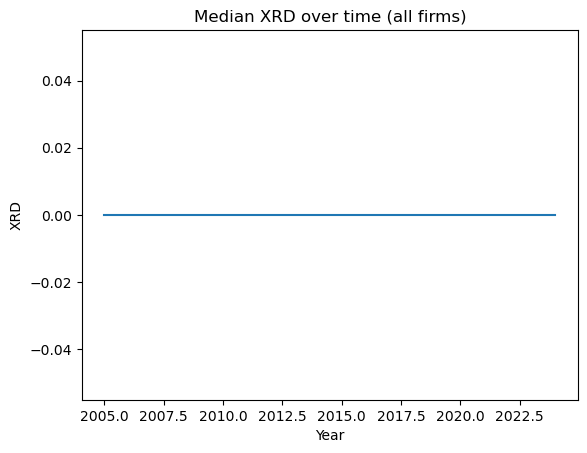

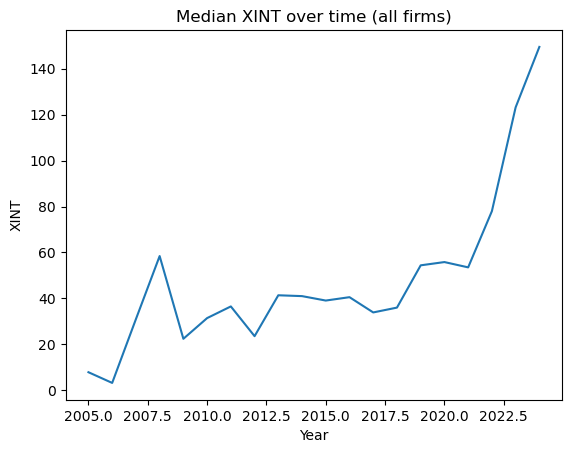

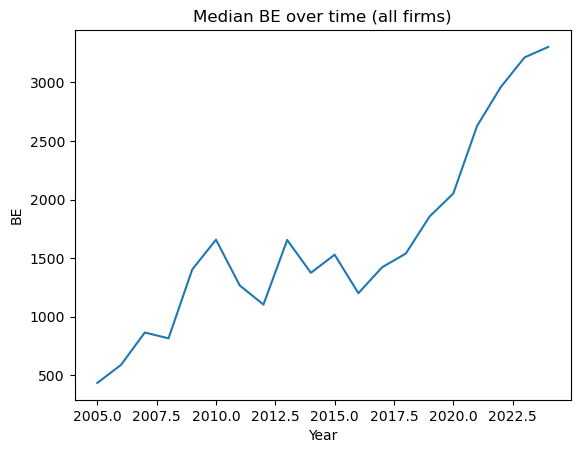

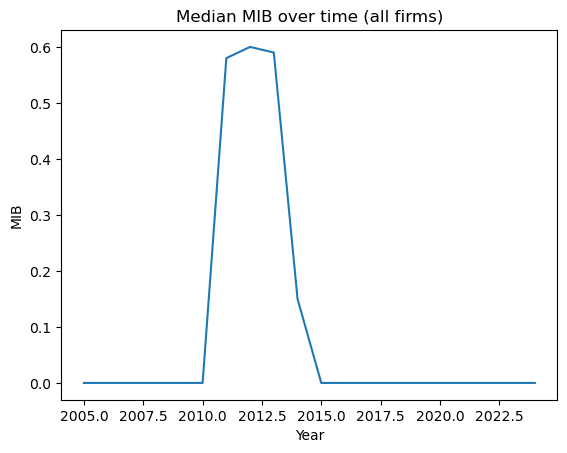

In [11]:

# ---------- Plot 3: Component diagnostics over time (ALL firms, medians) ----------
components = ["REVT", "COGS", "XSGA_COMPONENTS", "XRD", "XINT", "BE", "MIB"]
missing_components = [c for c in components if c not in panel.columns]
if missing_components:
    raise ValueError(f"Missing component columns in panel: {missing_components}")

comp_median = panel.groupby("Year")[components].median(numeric_only=True).reset_index()

for c in components:
    plt.figure()
    plt.plot(comp_median["Year"], comp_median[c])
    plt.title(f"Median {c} over time (all firms)")
    plt.xlabel("Year")
    plt.ylabel(c)
    plt.show()


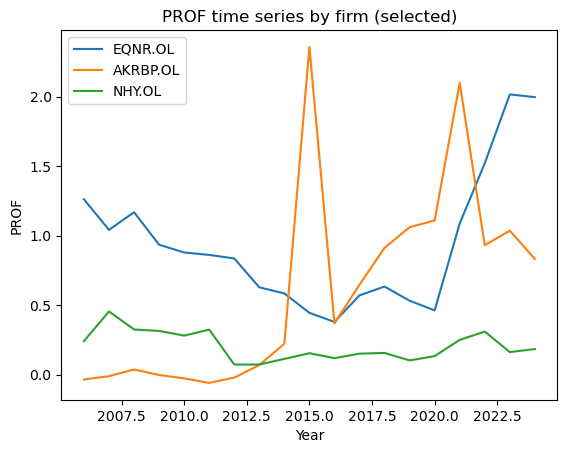

In [12]:

# ---------- Plot 5: Firm-level PROF time series (ONLY specified firms) ----------
plt.figure()
for f in firms_plot5:
    d = panel[panel["firm"] == f].sort_values("Year")
    if d.empty:
        print(f"[warn] No data found for {f}")
        continue
    plt.plot(d["Year"], d["PROF"], label=f)
plt.title("PROF time series by firm (selected)")
plt.xlabel("Year")
plt.ylabel("PROF")
plt.legend()
plt.show()

In [14]:
top5_one_row_per_year = (
    panel.assign(PROF=pd.to_numeric(panel["PROF"], errors="coerce"))
         .replace([np.inf, -np.inf], np.nan)
         .dropna(subset=["PROF"])
         .sort_values(["Year", "PROF"], ascending=[True, False])
         .groupby("Year", as_index=False)
         .head(5)
         .groupby("Year")
         .apply(lambda g: pd.Series({
             "top5_firms": ", ".join(g["firm"].tolist()),
             "top5_PROF": ", ".join([f"{x:.4f}" for x in g["PROF"].tolist()])
         }))
         .reset_index()
         .sort_values("Year")
         .reset_index(drop=True)
)

display(top5_one_row_per_year)

/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_30229/1156369912.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Year,top5_firms,top5_PROF
0,2005,"ATEA.OL, AKAST.OL, AFG.OL, NAS.OL, KOA.OL","22.6208, 3.5290, 3.2582, 3.1070, 2.1500"
1,2006,"NAS.OL, TEL.OL, KOG.OL, ATEA.OL, AKAST.OL","10.7473, 6.5124, 4.1271, 3.9942, 2.3378"
2,2007,"ARCHA.OL, ATEA.OL, TEL.OL, AKAST.OL, ARRA.OL","7.7711, 5.0762, 4.5686, 2.9598, 2.5658"
3,2008,"MOWI.OL, IOX.OL, NAS.OL, ATEA.OL, TEL.OL","11.9971, 7.7158, 6.3921, 4.0807, 3.6666"
4,2009,"NAS.OL, ATEA.OL, TEL.OL, AKAST.OL, ARCHA.OL","4.3033, 4.0994, 3.4098, 2.3603, 1.7322"
5,2010,"EMGS.OL, ATEA.OL, TEL.OL, KOMPLK.OL, AKAST.OL","10.0456, 4.1131, 3.3071, 2.0150, 1.8387"
6,2011,"ATEA.OL, BRGB.OL, AKAST.OL, GYL.OL, TOM.OL","4.2219, 1.9494, 1.8600, 1.6401, 1.5715"
7,2012,"BWLPG.OL, ATEA.OL, SCATC.OL, AFG.OL, GYL.OL","34.5929, 4.3421, 2.0760, 1.8070, 1.7794"
8,2013,"ATEA.OL, AFG.OL, TOM.OL, KID.OL, GYL.OL","4.9481, 1.9610, 1.8174, 1.3714, 1.3336"
9,2014,"ATEA.OL, TOM.OL, AFG.OL, GSFG.OL, GYL.OL","5.5615, 1.8989, 1.8259, 1.5402, 1.4482"


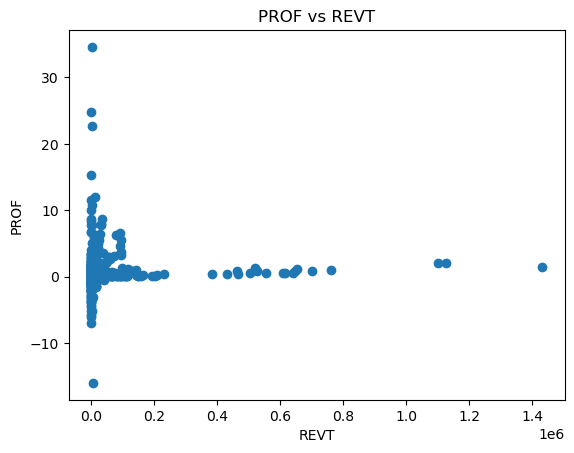

In [15]:
# Scatterplot: PROF (y) vs REVT (x), using existing `panel`
x = pd.to_numeric(panel["REVT"], errors="coerce")
y = pd.to_numeric(panel["PROF"], errors="coerce")

mask = np.isfinite(x) & np.isfinite(y)
plt.figure()
plt.scatter(x[mask], y[mask])
plt.title("PROF vs REVT")
plt.xlabel("REVT")
plt.ylabel("PROF")
plt.show()

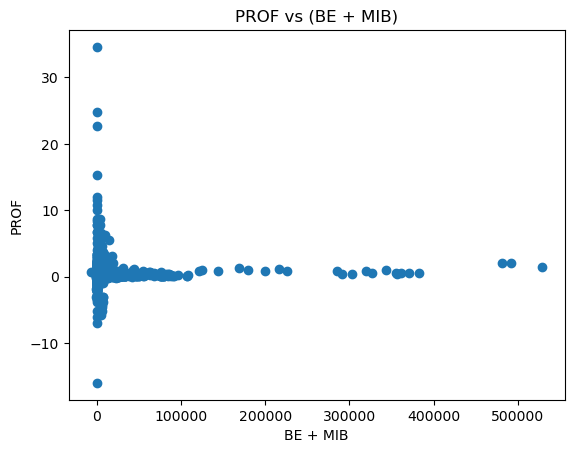

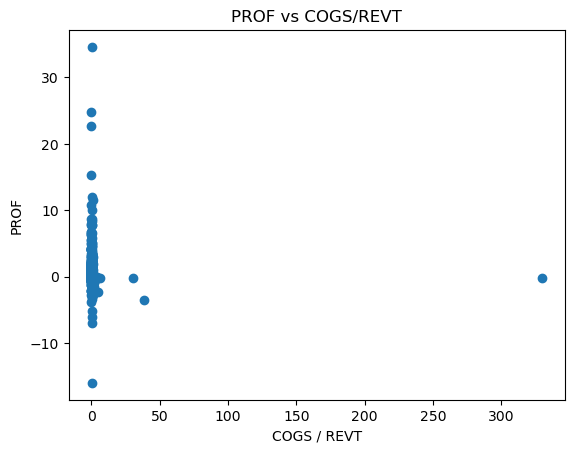

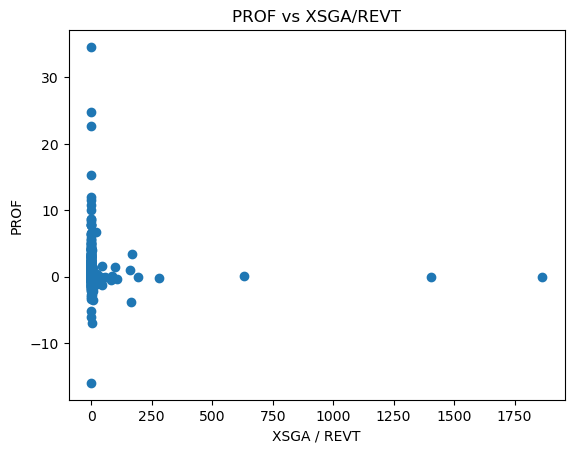

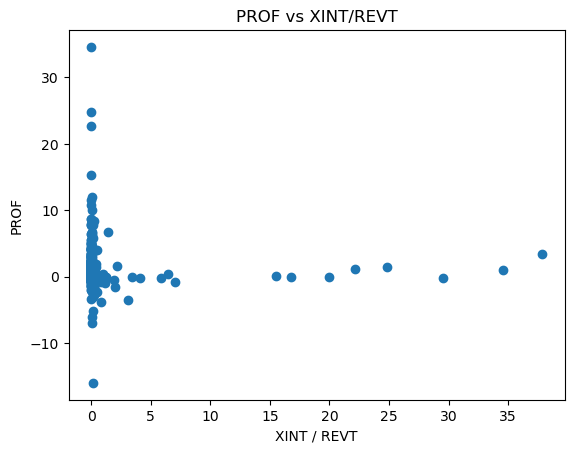

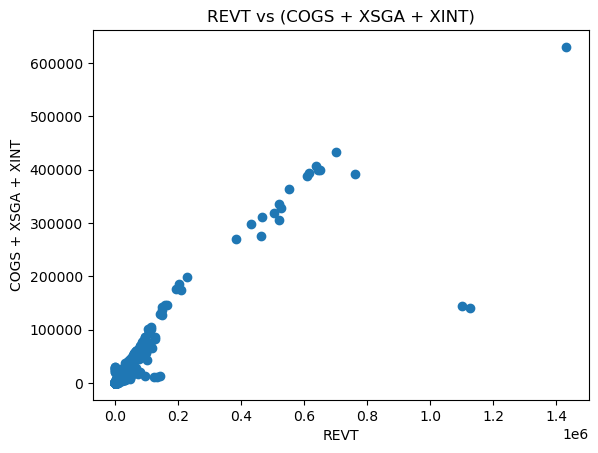

In [16]:
def scatter(x, y, title, xlabel, ylabel):
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)
    plt.figure()
    plt.scatter(x[mask], y[mask])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 1) PROF vs denominator
denom = pd.to_numeric(panel["BE"], errors="coerce") + pd.to_numeric(panel["MIB"], errors="coerce")
scatter(denom, panel["PROF"], "PROF vs (BE + MIB)", "BE + MIB", "PROF")

# 2) PROF vs COGS/REVT (gross margin proxy)
ratio_cogs = pd.to_numeric(panel["COGS"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_cogs, panel["PROF"], "PROF vs COGS/REVT", "COGS / REVT", "PROF")

# 3) PROF vs XSGA/REVT
ratio_xsga = pd.to_numeric(panel["XSGA_COMPONENTS"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_xsga, panel["PROF"], "PROF vs XSGA/REVT", "XSGA / REVT", "PROF")

# 4) PROF vs XINT/REVT
ratio_xint = pd.to_numeric(panel["XINT"], errors="coerce") / pd.to_numeric(panel["REVT"], errors="coerce")
scatter(ratio_xint, panel["PROF"], "PROF vs XINT/REVT", "XINT / REVT", "PROF")

# 5) REVT vs total costs (COGS + XSGA + XINT)
total_costs = (
    pd.to_numeric(panel["COGS"], errors="coerce")
    + pd.to_numeric(panel["XSGA_COMPONENTS"], errors="coerce")
    + pd.to_numeric(panel["XINT"], errors="coerce")
)
scatter(panel["REVT"], total_costs, "REVT vs (COGS + XSGA + XINT)", "REVT", "COGS + XSGA + XINT")

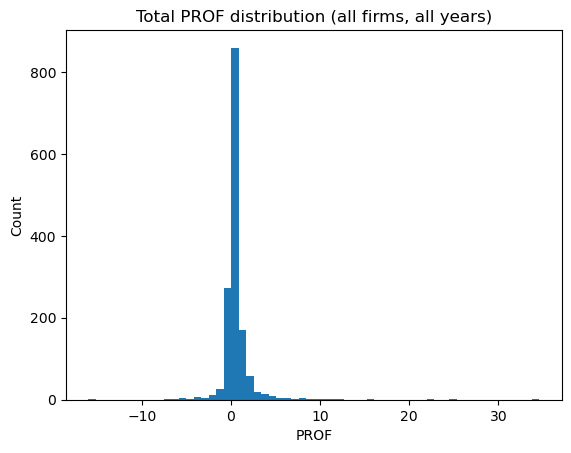

In [17]:
# Total distribution of PROF (all firms + all years currently in `panel`)
vals = pd.to_numeric(panel["PROF"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

plt.figure()
plt.hist(vals, bins=60)
plt.title("Total PROF distribution (all firms, all years)")
plt.xlabel("PROF")
plt.ylabel("Count")
plt.show()